In [1]:
import subprocess, sys
subprocess.check_call([sys.executable, "-m", "pip", "install", 
    "qiskit", "qiskit-aer", "qiskit-machine-learning", "-q"])

import numpy as np, pandas as pd
from sklearn.preprocessing import MinMaxScaler
from sklearn.kernel_ridge import KernelRidge
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import matplotlib.pyplot as plt, seaborn as sns

from qiskit.circuit.library import ZZFeatureMap
from qiskit.primitives import Sampler
from qiskit_machine_learning.kernels import FidelityQuantumKernel

print("✓ Imports successful")

ImportError: cannot import name 'Sampler' from 'qiskit.primitives' (/usr/local/lib/python3.12/dist-packages/qiskit/primitives/__init__.py)

In [2]:
import pandas as pd
import numpy as np

# Update filenames if needed
X_df = pd.read_csv("maize-quantum/data/processed/X_features_normalized.csv")
y_df = pd.read_csv("maize-quantum/data/processed/y_target.csv")

print("X_df shape:", X_df.shape)
print("y_df shape:", y_df.shape)

display(X_df.head())
display(y_df.head())

X_df shape: (129, 22)
y_df shape: (129, 1)


,0.0,0.344599668745997,0.040233109981911874,0.547110289320657,0.34459966249855556,0.6948959161761217,0.710222802154103,0.33333333333333337,0.38461538461538464,0.8888888888888888,...,1.0,0.0.1,0.0.2,0.0.3,0.0.4,0.0.5,0.0.6,0.0.7,0.0.8,0.0.9
0,0.083333,0.331998,0.040233,0.526451,0.331998,0.465715,0.484130,0.333333,0.461538,0.666667,...,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1,0.166667,0.064785,0.040233,0.088359,0.064785,0.047069,0.354094,0.333333,0.076923,0.888889,...,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2,0.250000,0.123408,0.040233,0.184469,0.123408,0.219374,0.542319,0.250000,0.076923,0.777778,...,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
3,0.333333,0.253664,0.040233,0.398022,0.253664,0.368693,0.494146,0.333333,0.307692,0.777778,...,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
4,0.416667,0.052351,0.040233,0.067973,0.052351,0.000000,0.279940,0.083333,0.000000,0.777778,...,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


,1.916579
0,0.999999
1,1.886660
2,2.186021
3,1.496352
4,1.552807


In [3]:
X_full = X_df.values
y_full = y_df.iloc[:, 0].values.flatten()

print(f"Data loaded: X={X_full.shape}, y={y_full.shape}")
print("X min/max:", X_full.min(), X_full.max())

Data loaded: X=(129, 22), y=(129,)
X min/max: 0.0 1.0000000000000002


In [5]:
assert len(X_full) == len(y_full), "X and y row counts do not match"

In [6]:
n_quantum_features = min(4, X_full.shape[1])   # safer first run
X_quantum = X_full[:, :n_quantum_features]

print(f"Quantum features: {X_quantum.shape}")
print(f"Classical features (full): {X_full.shape}")

Quantum features: (129, 4)
Classical features (full): (129, 22)


In [7]:
n_train = int(0.6 * len(X_quantum))
n_val = int(0.2 * len(X_quantum))

X_train_q = X_quantum[:n_train]
y_train = y_full[:n_train]

X_val_q = X_quantum[n_train:n_train+n_val]
y_val = y_full[n_train:n_train+n_val]

X_test_q = X_quantum[n_train+n_val:]
y_test = y_full[n_train+n_val:]

X_train_c = X_full[:n_train]
X_val_c = X_full[n_train:n_train+n_val]
X_test_c = X_full[n_train+n_val:]

print(f"Train: {len(X_train_q)}, Val: {len(X_val_q)}, Test: {len(X_test_q)}")

Train: 77, Val: 25, Test: 27


In [8]:
from qiskit.circuit.library import ZZFeatureMap
from qiskit_machine_learning.kernels import FidelityQuantumKernel

n_qubits = X_train_q.shape[1]
feature_map = ZZFeatureMap(feature_dimension=n_qubits, reps=2, entanglement="linear")
qkernel = FidelityQuantumKernel(feature_map=feature_map)

print(f"ZZFeatureMap: {n_qubits} qubits, 2 reps, linear entanglement")
print("✓ Quantum kernel initialized")

ZZFeatureMap: 4 qubits, 2 reps, linear entanglement
✓ Quantum kernel initialized


/tmp/ipykernel_233/2858008090.py:5: DeprecationWarning: The class ``qiskit.circuit.library.data_preparation._zz_feature_map.ZZFeatureMap`` is deprecated as of Qiskit 2.1. It will be removed in Qiskit 3.0. Use the zz_feature_map function as a replacement. Note that this will no longer return a BlueprintCircuit, but just a plain QuantumCircuit.
  feature_map = ZZFeatureMap(feature_dimension=n_qubits, reps=2, entanglement="linear")


In [9]:
print("Computing quantum kernel matrices...")

K_train_quantum = qkernel.evaluate(x_vec=X_train_q)
print(f"✓ K_train: {K_train_quantum.shape}")

K_val_quantum = qkernel.evaluate(x_vec=X_val_q, y_vec=X_train_q)
print(f"✓ K_val: {K_val_quantum.shape}")

K_test_quantum = qkernel.evaluate(x_vec=X_test_q, y_vec=X_train_q)
print(f"✓ K_test: {K_test_quantum.shape}")

Computing quantum kernel matrices...
✓ K_train: (77, 77)
✓ K_val: (25, 77)
✓ K_test: (27, 77)


In [10]:
np.save("maize-quantum/outputs/models/K_train_quantum.npy", K_train_quantum)
np.save("maize-quantum/outputs/models/K_val_quantum.npy", K_val_quantum)
np.save("maize-quantum/outputs/models/K_test_quantum.npy", K_test_quantum)

print("✓ Kernel matrices saved")

✓ Kernel matrices saved


In [11]:
from sklearn.kernel_ridge import KernelRidge
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error
import numpy as np

alphas = [0.001, 0.01, 0.1, 1.0, 10.0]
best_alpha = None
best_val_rmse = np.inf

for alpha in alphas:
    model_test = KernelRidge(alpha=alpha, kernel="precomputed")
    model_test.fit(K_train_quantum, y_train)
    y_val_pred = model_test.predict(K_val_quantum)
    val_rmse = np.sqrt(mean_squared_error(y_val, y_val_pred))
    print(f"alpha={alpha}: Val RMSE={val_rmse:.4f}")
    if val_rmse < best_val_rmse:
        best_val_rmse = val_rmse
        best_alpha = alpha

model_qkrr = KernelRidge(alpha=best_alpha, kernel="precomputed")
model_qkrr.fit(K_train_quantum, y_train)

y_train_pred_q = model_qkrr.predict(K_train_quantum)
y_val_pred_q = model_qkrr.predict(K_val_quantum)
y_test_pred_q = model_qkrr.predict(K_test_quantum)

print(f"\nQuantum KRR (alpha={best_alpha}):")
print(f"  Train RMSE: {np.sqrt(mean_squared_error(y_train, y_train_pred_q)):.4f}")
print(f"  Val RMSE:   {np.sqrt(mean_squared_error(y_val, y_val_pred_q)):.4f}")
print(f"  Test RMSE:  {np.sqrt(mean_squared_error(y_test, y_test_pred_q)):.4f}")
print(f"  Test MAE:   {mean_absolute_error(y_test, y_test_pred_q):.4f}")
print(f"  Test R²:    {r2_score(y_test, y_test_pred_q):.4f}")

alpha=0.001: Val RMSE=1.1120
alpha=0.01: Val RMSE=1.1864
alpha=0.1: Val RMSE=1.3989
alpha=1.0: Val RMSE=1.8957
alpha=10.0: Val RMSE=3.0231

Quantum KRR (alpha=0.001):
  Train RMSE: 0.0657
  Val RMSE:   1.1120
  Test RMSE:  1.0734
  Test MAE:   0.8362
  Test R²:    -1.5766


In [12]:
alphas = [1e-5, 1e-4, 1e-3, 1e-2, 1e-1, 1, 10, 100]
feature_map = ZZFeatureMap(feature_dimension=n_qubits, reps=1, entanglement="linear")


/tmp/ipykernel_233/3183279477.py:2: DeprecationWarning: The class ``qiskit.circuit.library.data_preparation._zz_feature_map.ZZFeatureMap`` is deprecated as of Qiskit 2.1. It will be removed in Qiskit 3.0. Use the zz_feature_map function as a replacement. Note that this will no longer return a BlueprintCircuit, but just a plain QuantumCircuit.
  feature_map = ZZFeatureMap(feature_dimension=n_qubits, reps=1, entanglement="linear")


In [13]:
n_quantum_features = min(6, X_full.shape[1])
X_quantum = X_full[:, :n_quantum_features]

In [15]:
from sklearn.preprocessing import MinMaxScaler
import numpy as np

scaler_q = MinMaxScaler(feature_range=(0, np.pi))
X_quantum = scaler_q.fit_transform(X_quantum)

In [16]:
feature_map = ZZFeatureMap(
    feature_dimension=X_train_q.shape[1],
    reps=1,
    entanglement="linear"
)
qkernel = FidelityQuantumKernel(feature_map=feature_map)

/tmp/ipykernel_233/198162147.py:1: DeprecationWarning: The class ``qiskit.circuit.library.data_preparation._zz_feature_map.ZZFeatureMap`` is deprecated as of Qiskit 2.1. It will be removed in Qiskit 3.0. Use the zz_feature_map function as a replacement. Note that this will no longer return a BlueprintCircuit, but just a plain QuantumCircuit.
  feature_map = ZZFeatureMap(


In [17]:
alphas = [1e-5, 1e-4, 1e-3, 1e-2, 1e-1, 1, 10, 100]

In [18]:
import numpy as np
from sklearn.preprocessing import MinMaxScaler

# Use first 6 features for now
n_quantum_features = min(6, X_full.shape[1])
X_quantum = X_full[:, :n_quantum_features]

# Rescale specifically for quantum angle encoding
scaler_q = MinMaxScaler(feature_range=(0, np.pi))
X_quantum_scaled = scaler_q.fit_transform(X_quantum)

print("Quantum subset shape:", X_quantum.shape)
print("Scaled quantum min/max:", X_quantum_scaled.min(), X_quantum_scaled.max())

Quantum subset shape: (129, 6)
Scaled quantum min/max: 0.0 3.141592653589793


In [19]:
n_train = int(0.6 * len(X_quantum_scaled))
n_val = int(0.2 * len(X_quantum_scaled))

X_train_q = X_quantum_scaled[:n_train]
y_train = y_full[:n_train]

X_val_q = X_quantum_scaled[n_train:n_train+n_val]
y_val = y_full[n_train:n_train+n_val]

X_test_q = X_quantum_scaled[n_train+n_val:]
y_test = y_full[n_train+n_val:]

# Classical comparison uses the same 6 features, unscaled or scaled.
# Using the same scaled subset makes the comparison cleaner.
X_train_c6 = X_train_q.copy()
X_val_c6 = X_val_q.copy()
X_test_c6 = X_test_q.copy()

print(f"Train: {len(X_train_q)}, Val: {len(X_val_q)}, Test: {len(X_test_q)}")

Train: 77, Val: 25, Test: 27


In [20]:
from qiskit.circuit.library import ZZFeatureMap
from qiskit_machine_learning.kernels import FidelityQuantumKernel

n_qubits = X_train_q.shape[1]

feature_map = ZZFeatureMap(
    feature_dimension=n_qubits,
    reps=1,
    entanglement="linear"
)

qkernel = FidelityQuantumKernel(feature_map=feature_map)

print(f"ZZFeatureMap created with {n_qubits} qubits, reps=1, linear entanglement")

ZZFeatureMap created with 6 qubits, reps=1, linear entanglement


/tmp/ipykernel_233/2367158069.py:6: DeprecationWarning: The class ``qiskit.circuit.library.data_preparation._zz_feature_map.ZZFeatureMap`` is deprecated as of Qiskit 2.1. It will be removed in Qiskit 3.0. Use the zz_feature_map function as a replacement. Note that this will no longer return a BlueprintCircuit, but just a plain QuantumCircuit.
  feature_map = ZZFeatureMap(


In [21]:
print("Computing quantum kernel matrices...")

K_train_quantum = qkernel.evaluate(x_vec=X_train_q)
K_val_quantum = qkernel.evaluate(x_vec=X_val_q, y_vec=X_train_q)
K_test_quantum = qkernel.evaluate(x_vec=X_test_q, y_vec=X_train_q)

print("K_train:", K_train_quantum.shape)
print("K_val:", K_val_quantum.shape)
print("K_test:", K_test_quantum.shape)

Computing quantum kernel matrices...
K_train: (77, 77)
K_val: (25, 77)
K_test: (27, 77)


In [22]:
from sklearn.kernel_ridge import KernelRidge
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

alphas = [1e-5, 1e-4, 1e-3, 1e-2, 1e-1, 1, 10, 100]
best_alpha_q = None
best_val_rmse_q = np.inf

for alpha in alphas:
    model_q = KernelRidge(alpha=alpha, kernel="precomputed")
    model_q.fit(K_train_quantum, y_train)
    y_val_pred_q_tmp = model_q.predict(K_val_quantum)
    val_rmse_q = np.sqrt(mean_squared_error(y_val, y_val_pred_q_tmp))
    print(f"[QKRR] alpha={alpha}: Val RMSE={val_rmse_q:.4f}")
    if val_rmse_q < best_val_rmse_q:
        best_val_rmse_q = val_rmse_q
        best_alpha_q = alpha

model_qkrr = KernelRidge(alpha=best_alpha_q, kernel="precomputed")
model_qkrr.fit(K_train_quantum, y_train)

y_train_pred_q = model_qkrr.predict(K_train_quantum)
y_val_pred_q = model_qkrr.predict(K_val_quantum)
y_test_pred_q = model_qkrr.predict(K_test_quantum)

print(f"\nQuantum KRR best alpha = {best_alpha_q}")
print(f"Train RMSE: {np.sqrt(mean_squared_error(y_train, y_train_pred_q)):.4f}")
print(f"Val RMSE:   {np.sqrt(mean_squared_error(y_val, y_val_pred_q)):.4f}")
print(f"Test RMSE:  {np.sqrt(mean_squared_error(y_test, y_test_pred_q)):.4f}")
print(f"Test MAE:   {mean_absolute_error(y_test, y_test_pred_q):.4f}")
print(f"Test R²:    {r2_score(y_test, y_test_pred_q):.4f}")

[QKRR] alpha=1e-05: Val RMSE=2.5316
[QKRR] alpha=0.0001: Val RMSE=2.5317
[QKRR] alpha=0.001: Val RMSE=2.5327
[QKRR] alpha=0.01: Val RMSE=2.5424
[QKRR] alpha=0.1: Val RMSE=2.6166
[QKRR] alpha=1: Val RMSE=3.0137
[QKRR] alpha=10: Val RMSE=3.7012
[QKRR] alpha=100: Val RMSE=3.9381

Quantum KRR best alpha = 1e-05
Train RMSE: 0.0000
Val RMSE:   2.5316
Test RMSE:  0.9237
Test MAE:   0.7041
Test R²:    -0.9083


In [23]:
best_alpha_rbf = None
best_val_rmse_rbf = np.inf

for alpha in alphas:
    model_rbf = KernelRidge(alpha=alpha, kernel="rbf", gamma=None)
    model_rbf.fit(X_train_c6, y_train)
    y_val_pred_rbf_tmp = model_rbf.predict(X_val_c6)
    val_rmse_rbf = np.sqrt(mean_squared_error(y_val, y_val_pred_rbf_tmp))
    print(f"[RBF KRR] alpha={alpha}: Val RMSE={val_rmse_rbf:.4f}")
    if val_rmse_rbf < best_val_rmse_rbf:
        best_val_rmse_rbf = val_rmse_rbf
        best_alpha_rbf = alpha

model_rbf = KernelRidge(alpha=best_alpha_rbf, kernel="rbf", gamma=None)
model_rbf.fit(X_train_c6, y_train)

y_train_pred_rbf = model_rbf.predict(X_train_c6)
y_val_pred_rbf = model_rbf.predict(X_val_c6)
y_test_pred_rbf = model_rbf.predict(X_test_c6)

print(f"\nClassical RBF-KRR best alpha = {best_alpha_rbf}")
print(f"Train RMSE: {np.sqrt(mean_squared_error(y_train, y_train_pred_rbf)):.4f}")
print(f"Val RMSE:   {np.sqrt(mean_squared_error(y_val, y_val_pred_rbf)):.4f}")
print(f"Test RMSE:  {np.sqrt(mean_squared_error(y_test, y_test_pred_rbf)):.4f}")
print(f"Test MAE:   {mean_absolute_error(y_test, y_test_pred_rbf):.4f}")
print(f"Test R²:    {r2_score(y_test, y_test_pred_rbf):.4f}")

[RBF KRR] alpha=1e-05: Val RMSE=1.2155
[RBF KRR] alpha=0.0001: Val RMSE=1.0371
[RBF KRR] alpha=0.001: Val RMSE=1.1288
[RBF KRR] alpha=0.01: Val RMSE=1.2412
[RBF KRR] alpha=0.1: Val RMSE=1.3251
[RBF KRR] alpha=1: Val RMSE=1.5016
[RBF KRR] alpha=10: Val RMSE=2.1053
[RBF KRR] alpha=100: Val RMSE=3.3657

Classical RBF-KRR best alpha = 0.0001
Train RMSE: 0.0719
Val RMSE:   1.0371
Test RMSE:  1.1873
Test MAE:   0.9819
Test R²:    -2.1524


In [24]:
comparison_6f = pd.DataFrame({
    "Model": ["Quantum KRR", "Classical RBF-KRR"],
    "Best Alpha": [best_alpha_q, best_alpha_rbf],
    "Val RMSE": [
        np.sqrt(mean_squared_error(y_val, y_val_pred_q)),
        np.sqrt(mean_squared_error(y_val, y_val_pred_rbf)),
    ],
    "Test RMSE": [
        np.sqrt(mean_squared_error(y_test, y_test_pred_q)),
        np.sqrt(mean_squared_error(y_test, y_test_pred_rbf)),
    ],
    "Test MAE": [
        mean_absolute_error(y_test, y_test_pred_q),
        mean_absolute_error(y_test, y_test_pred_rbf),
    ],
    "Test R2": [
        r2_score(y_test, y_test_pred_q),
        r2_score(y_test, y_test_pred_rbf),
    ]
})

display(comparison_6f)

,Model,Best Alpha,Val RMSE,Test RMSE,Test MAE,Test R2
0,Quantum KRR,0.00001,2.531566,0.923726,0.704112,-0.908268
1,Classical RBF-KRR,0.00010,1.037093,1.187254,0.981910,-2.152391


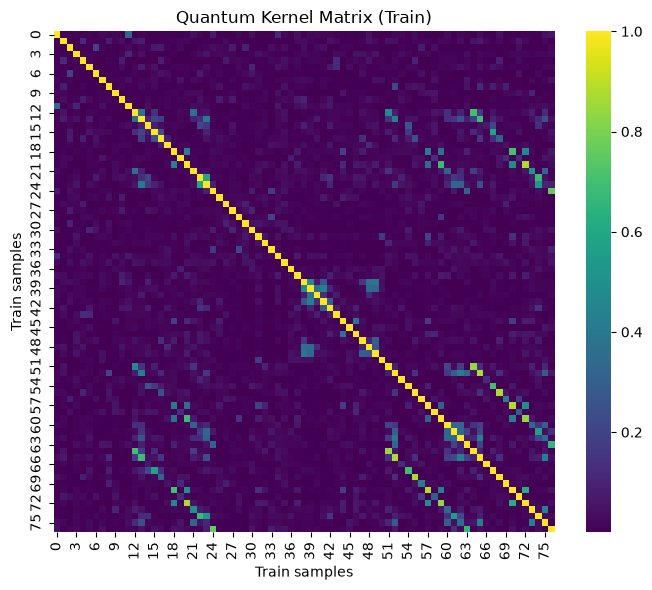

In [25]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(7, 6))
sns.heatmap(K_train_quantum, cmap="viridis")
plt.title("Quantum Kernel Matrix (Train)")
plt.xlabel("Train samples")
plt.ylabel("Train samples")
plt.tight_layout()
plt.show()

In [26]:
np.save("maize-quantum/outputs/models/K_train_quantum_6f.npy", K_train_quantum)
np.save("maize-quantum/outputs/models/K_val_quantum_6f.npy", K_val_quantum)
np.save("maize-quantum/outputs/models/K_test_quantum_6f.npy", K_test_quantum)

comparison_6f.to_csv("maize-quantum/outputs/models/comparison_6f.csv", index=False)

print("Saved 6-feature kernel matrices and comparison table.")

Saved 6-feature kernel matrices and comparison table.
